In [2]:
# Import liabraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [4]:
# Load dataset
data = load_breast_cancer()

# Convert the dataframe from better readability
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [6]:
# Display the first 5 rows
print('First 5 Rows : ')
df.head(5)

First 5 Rows : 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# Info
print('Info of the Dataset :\n')
df.info()

Info of the Dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smo

In [12]:
# Missing values
print('Number of Missing values under each column :\n',df.isnull().sum())

Number of Missing values under each column :
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [14]:
# Class distribution
print('Target values counts :\n',df['target'].value_counts())

Target values counts :
 target
1    357
0    212
Name: count, dtype: int64


In [17]:
# Seperate features(X) and Target (y)
X = df.drop(columns='target',axis=1)
y = df['target']

In [18]:
# Feature Scaling
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

In [19]:
# Train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2, random_state=42)
print('Data preprocessing completed successfully')
print('Training set shape : ',X_train.shape)
print('Testing set shape : ',X_test.shape)

Data preprocessing completed successfully
Training set shape :  (455, 30)
Testing set shape :  (114, 30)


In [20]:
# Naive bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [23]:
# Make prediction
y_pred = nb.predict(X_test)

In [24]:
# Evaluation
print('Accuracy Score : ',accuracy_score(y_test,y_pred))

Accuracy Score :  0.9649122807017544


In [25]:
print('Accuracy score in percentage : ',round(accuracy_score(y_test, y_pred)*100,2),"%")

Accuracy score in percentage :  96.49 %


In [26]:
print('Confusion matrix :\n',confusion_matrix(y_test,y_pred))

Confusion matrix :
 [[40  3]
 [ 1 70]]


In [28]:
print('Classification report :\n',classification_report(y_test,y_pred, target_names=data.target_names))

Classification report :
               precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



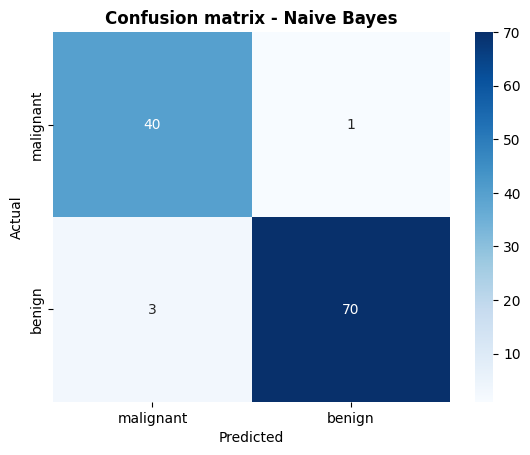

In [36]:
# visualize
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(data=cm,annot=True, cmap='Blues',xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion matrix - Naive Bayes', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

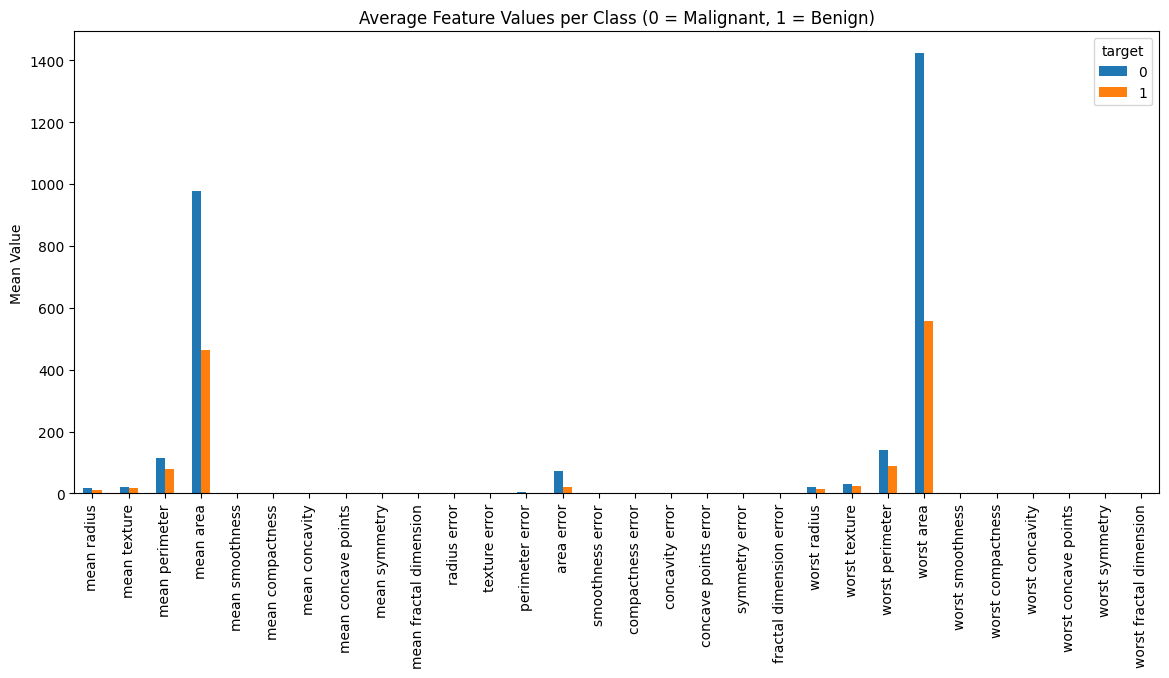

In [40]:
# Calculate mean of each feature for each class
means = df.groupby('target').mean().T
means.plot(kind='bar', figsize=(14,6))
plt.title("Average Feature Values per Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Mean Value")
plt.show()
